# Hierarchy-Aware Adaptive Chunking

This notebook implements a hierarchy-aware adaptive chunking pipeline for EMV specification documents.

The goal is to create chunks that keep the original document structure as much as possible while still respecting token limits for retrieval.  
The base unit is the section, but long sections are split using ordered block grouping. Tables are handled separately as atomic chunks because they often represent complete technical definitions on their own.


## 1. Imports

In this section, we import the standard Python libraries needed for:
- loading JSON data
- basic statistics
- plotting chunk size distributions
- working with paths

Only pure Python and common notebook libraries are used.


In [1]:
import json
import math
import statistics
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt


## 2. Load JSON data

The input file contains section-level objects for the processed EMV specification.

Each section includes:
- metadata such as title, level, parent relationship, and numbering
- ordered content blocks
- extracted tables

We load the file once and keep the full section list in memory for the chunking pipeline.


In [2]:
INPUT_PATH = "../../../data/processed/book4/done/final_chunk_ready.json"

input_path = Path(INPUT_PATH)
with input_path.open("r", encoding="utf-8") as f:
    sections = json.load(f)

print(f"Loaded {len(sections)} sections from: {input_path}")
print("First section keys:", list(sections[0].keys()) if sections else [])


Loaded 131 sections from: ../../../data/processed/book4/done/final_chunk_ready.json
First section keys: ['section_id', 'parent_section_id', 'doc_id', 'doc_version', 'doc_date', 'title', 'section_number', 'level', 'parent_titles', 'start_page', 'end_page', 'start_top', 'end_top', 'child_section_ids', 'blocks', 'tables']


## 3. Utility functions

Before chunking, it is useful to define helper functions for:
- cleaning and normalizing block content
- extracting text from a section
- checking whether a section is a leaf
- safely reading metadata from slightly different JSON schemas

The functions below are written to be practical and robust for project use.


In [3]:
def safe_get(data: Dict[str, Any], *keys: str, default=None):
    """Return the first existing non-null key from a dictionary."""
    for key in keys:
        if isinstance(data, dict) and key in data and data[key] is not None:
            return data[key]
    return default


def clean_text(text: Any) -> str:
    """Basic text cleanup used across blocks and tables."""
    if text is None:
        return ""
    text = str(text).replace("\r", "\n")
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines).strip()


def get_blocks(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Return the list of blocks from a section, even if key names vary slightly."""
    blocks = safe_get(section, "blocks", "content_blocks", default=[])
    return blocks if isinstance(blocks, list) else []


def get_tables(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Return the list of tables from a section."""
    tables = safe_get(section, "tables", default=[])
    return tables if isinstance(tables, list) else []


def get_page_num(section: Dict[str, Any]) -> Optional[int]:
    """Pick a representative page number for the section."""
    return safe_get(section, "page_num", "start_page", "page", default=None)


def get_parent_titles(section: Dict[str, Any]) -> List[str]:
    parent_titles = safe_get(section, "parent_titles", default=[])
    return parent_titles if isinstance(parent_titles, list) else []


def get_child_section_ids(section: Dict[str, Any]) -> List[str]:
    child_ids = safe_get(section, "child_section_ids", default=[])
    return child_ids if isinstance(child_ids, list) else []


def section_metadata(section: Dict[str, Any]) -> Dict[str, Any]:
    """Extract the core metadata required for every chunk."""
    return {
        "section_id": safe_get(section, "section_id", default=""),
        "doc_id": safe_get(section, "doc_id", default=""),
        "title": safe_get(section, "title", default=""),
        "section_number": safe_get(section, "section_number", default=""),
        "page_num": get_page_num(section),
        "level": safe_get(section, "level", default=None),
        "parent_titles": get_parent_titles(section),
        "parent_section_id": safe_get(section, "parent_section_id", default=None),
        "child_section_ids": get_child_section_ids(section),
    }


def classify_size_band(token_count: int) -> str:
    if token_count < 180:
        return "below_180"
    if token_count < 350:
        return "between_180_349"
    if token_count <= 550:
        return "between_350_550"
    return "above_550"


def detect_oversize_reason(chunk_type: str, token_count: int, block_count: int) -> Optional[str]:
    if chunk_type == "table" and token_count > PREFERRED_MAX:
        return "table_atomic"
    if token_count > PREFERRED_MAX and block_count <= 1:
        return "single_block"
    if token_count > PREFERRED_MAX:
        return "multi_block_limit"
    return None


## 4. Token estimation

For this project, token counting does not need an external tokenizer.

A lightweight approximation is enough for chunk boundary decisions:
- count words
- multiply by 1.3

This keeps the notebook simple and fully local.


In [4]:
def estimate_tokens(text: str) -> int:
    return int(len(text.split()) * 1.3)


## 5. Block normalization

The section content is made of blocks such as paragraphs and bullet lists.

To chunk correctly, we first convert every block into a clean text representation:
- paragraph -> use its text
- bullet_list -> join items with bullet formatting
- preserve intro_block_id if it exists, because it can be useful later for traceability


In [5]:
def normalize_block(block: Dict[str, Any], fallback_index: Optional[int] = None) -> Dict[str, Any]:
    """
    Convert one raw block into a normalized structure with clean text.

    Rules:
    - paragraph: use 'text'
    - bullet_list: join items with '\n- '
    - preserve intro_block_id when available
    - create a fallback block_id when the source block has no ID
    """
    block_type = safe_get(block, "type", default="paragraph")
    intro_block_id = safe_get(block, "intro_block_id", default=None)

    raw_block_id = safe_get(block, "block_id", default=None)
    if raw_block_id:
        block_id = str(raw_block_id)
    elif fallback_index is not None:
        block_id = f"block_{fallback_index}"
    else:
        block_id = None

    text = ""
    if block_type == "paragraph":
        text = clean_text(safe_get(block, "text", default=""))
    elif block_type == "bullet_list":
        items = safe_get(block, "items", default=[])
        if not isinstance(items, list):
            items = []
        cleaned_items = [clean_text(item) for item in items if clean_text(item)]
        text = "- " + "\n- ".join(cleaned_items) if cleaned_items else ""
    else:
        raw_text = clean_text(safe_get(block, "text", default=""))
        if raw_text:
            text = raw_text
        else:
            items = safe_get(block, "items", default=[])
            if not isinstance(items, list):
                items = []
            cleaned_items = [clean_text(item) for item in items if clean_text(item)]
            text = "\n".join(cleaned_items).strip()

    return {
        "block_id": block_id,
        "intro_block_id": intro_block_id,
        "type": block_type,
        "text": text,
        "token_count": estimate_tokens(text) if text else 0,
    }


## 6. Section text extraction

This function rebuilds the textual body of a section by concatenating normalized blocks in order.

Important note:
- tables are ignored here because they are handled separately as atomic chunks


In [6]:
def get_section_text(section: Dict[str, Any]) -> str:
    normalized_blocks = [
        normalize_block(block, fallback_index=i)
        for i, block in enumerate(get_blocks(section), start=1)
    ]
    texts = [block["text"] for block in normalized_blocks if block["text"]]
    return "\n\n".join(texts).strip()


def is_leaf(section: Dict[str, Any]) -> bool:
    return len(get_child_section_ids(section)) == 0


## 7. Candidate chunk creation

Not every section should become a text chunk candidate.

The rules are:
- include all leaf sections
- include non-leaf sections only if they are substantial enough
- here, substantial enough means estimated text length is at least 80 tokens

This helps avoid creating noisy parent chunks that contain only headings or very small summaries.


In [7]:
MIN_PARENT_TOKENS = 80
PREFERRED_MIN = 350
PREFERRED_MAX = 520
SMALL_MIN = 180
OVERLAP_MIN = 80
OVERLAP_MAX = 100
DEFAULT_OVERLAP_TARGET = 90


def create_candidate(section: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    text = get_section_text(section)
    token_count = estimate_tokens(text)

    leaf = is_leaf(section)
    include = leaf or (token_count >= MIN_PARENT_TOKENS)

    if not include or not text:
        return None

    metadata = section_metadata(section)
    return {
        **metadata,
        "text": text,
        "token_count": token_count,
        "is_leaf": leaf,
        "candidate_source": "leaf" if leaf else "non_leaf_large",
    }


## 8. Chunking logic

The chunking strategy is adaptive:
- keep a section as one chunk when it already fits
- split only when it exceeds the maximum size
- splitting is done by grouping full blocks in order
- no block is split internally

An overlap of about 80 to 100 tokens is added only between split chunks.  
This overlap is created using the tail of the previous chunk and helps retrieval preserve context across chunk boundaries.


In [8]:
def build_overlap_text(previous_text: str, target_tokens: int = DEFAULT_OVERLAP_TARGET) -> str:
    """Return a short overlap tail from the previous chunk."""
    words = previous_text.split()
    if not words:
        return ""

    overlap_word_count = max(1, math.ceil(target_tokens / 1.3))
    overlap_words = words[-overlap_word_count:]
    overlap_text = " ".join(overlap_words).strip()

    overlap_tokens = estimate_tokens(overlap_text)
    if overlap_tokens < OVERLAP_MIN:
        extra_words = max(1, math.ceil((OVERLAP_MIN - overlap_tokens) / 1.3))
        overlap_words = words[-(overlap_word_count + extra_words):]
        overlap_text = " ".join(overlap_words).strip()
    elif overlap_tokens > OVERLAP_MAX:
        while overlap_text and estimate_tokens(overlap_text) > OVERLAP_MAX:
            overlap_words = overlap_words[1:]
            overlap_text = " ".join(overlap_words).strip()

    return overlap_text


def make_text_chunk(
    section: Dict[str, Any],
    chunk_text: str,
    chunk_index: int,
    total_chunks: int,
    source_block_ids: Optional[List[str]] = None,
    block_count: int = 0,
    is_split: bool = False,
    overlap_prev_tokens: int = 0,
    overlap_next_tokens: int = 0,
    candidate_source: str = "unknown",
    chunking_reason: str = "kept_in_range",
) -> Dict[str, Any]:
    metadata = section_metadata(section)
    section_id = metadata["section_id"]
    clean_chunk_text = chunk_text.strip()
    token_count = estimate_tokens(clean_chunk_text)

    return {
        "chunk_id": f"{section_id}_text_{chunk_index}",
        "section_id": section_id,
        "chunk_index": f"{chunk_index}/{total_chunks}",
        "doc_id": metadata["doc_id"],
        "title": metadata["title"],
        "section_number": metadata["section_number"],
        "page_num": metadata["page_num"],
        "level": metadata["level"],
        "parent_titles": metadata["parent_titles"],
        "parent_section_id": metadata["parent_section_id"],
        "child_section_ids": metadata["child_section_ids"],
        "text": clean_chunk_text,
        "token_count": token_count,
        "type": "text",
        "source_block_ids": source_block_ids or [],
        "block_count": block_count if block_count else len(source_block_ids or []),
        "is_split": is_split,
        "split_group_id": section_id if is_split else None,
        "overlap_prev_tokens": overlap_prev_tokens,
        "overlap_next_tokens": overlap_next_tokens,
        "candidate_source": candidate_source,
        "chunking_reason": chunking_reason,
        "size_band": classify_size_band(token_count),
        "oversize_reason": detect_oversize_reason("text", token_count, block_count if block_count else len(source_block_ids or [])),
    }


def split_section_into_chunks(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Split a section into multiple text chunks by grouping blocks sequentially.

    Rules:
    - do not break inside paragraphs
    - do not break inside bullet lists
    - stop before exceeding 550 tokens
    - add 80-100 token overlap only between split chunks
    """
    normalized_blocks = [
        normalize_block(block, fallback_index=i)
        for i, block in enumerate(get_blocks(section), start=1)
    ]
    normalized_blocks = [block for block in normalized_blocks if block["text"]]

    if not normalized_blocks:
        return []

    groups: List[List[Dict[str, Any]]] = []
    current_group: List[Dict[str, Any]] = []
    current_texts: List[str] = []

    for block in normalized_blocks:
        candidate_texts = current_texts + [block["text"]]
        candidate_text = "\n\n".join(candidate_texts).strip()
        candidate_tokens = estimate_tokens(candidate_text)

        if current_group and candidate_tokens > PREFERRED_MAX:
            groups.append(current_group)
            current_group = [block]
            current_texts = [block["text"]]
        else:
            current_group.append(block)
            current_texts.append(block["text"])

    if current_group:
        groups.append(current_group)

    chunks: List[Dict[str, Any]] = []
    previous_base_text = ""
    total_chunks = len(groups)

    for idx, group in enumerate(groups, start=1):
        base_text = "\n\n".join(block["text"] for block in group if block["text"]).strip()

        overlap_text = ""
        overlap_prev_tokens = 0
        if idx > 1:
            overlap_text = build_overlap_text(previous_base_text, DEFAULT_OVERLAP_TARGET)
            overlap_prev_tokens = estimate_tokens(overlap_text) if overlap_text else 0

        final_text = f"{overlap_text}\n\n{base_text}".strip() if overlap_text else base_text
        source_block_ids = [block["block_id"] for block in group if block.get("block_id")]

        chunk = make_text_chunk(
            section=section,
            chunk_text=final_text,
            chunk_index=idx,
            total_chunks=total_chunks,
            source_block_ids=source_block_ids,
            block_count=len(source_block_ids),
            is_split=(total_chunks > 1),
            overlap_prev_tokens=overlap_prev_tokens,
            overlap_next_tokens=0,
            candidate_source="leaf" if is_leaf(section) else "non_leaf_large",
            chunking_reason="split_over_550",
        )
        chunks.append(chunk)
        previous_base_text = base_text

    return chunks


## 9. Table handling

Tables are stored as separate atomic chunks.

This is important in EMV specifications because many tables contain definitions, command fields, constraints, or mappings that should not be split across chunks.


In [9]:
def table_to_text(table: Dict[str, Any]) -> str:
    """Convert a table object into a readable text form for many table schemas."""
    title = clean_text(safe_get(table, "title", default=""))
    structured = safe_get(table, "structured_data", default=[])
    cells = safe_get(table, "cells", default=[])
    table_text = clean_text(safe_get(table, "table_text", default=""))

    parts = []

    if title:
        parts.append(title)

    def format_structured_row(row: Dict[str, Any], level: int = 0) -> list[str]:
        lines = []
        if not isinstance(row, dict):
            text = clean_text(str(row))
            return [text] if text else []

        ignored_keys = {"_level"}
        fields = []

        for key, value in row.items():
            if key in ignored_keys:
                continue
            if value is None and value == "children":
                continue

            value_text = clean_text(str(value))

            key_text = clean_text(str(key)).replace("_", " ")
            fields.append(f"{key_text}: {value_text}")

        if fields:
            indent = "  " * level
            lines.append(f"{indent}- " + " | ".join(fields))

        children = row.get("children", [])
        if isinstance(children, list):
            for child in children:
                lines.extend(format_structured_row(child, level + 1))

        return lines

    # 1. Prefer structured_data when available
    if isinstance(structured, list) and structured:
        for row in structured:
            parts.extend(format_structured_row(row))

    # 2. Fallback to cells
    elif isinstance(cells, list) and cells:
        for row in cells:
            if isinstance(row, list):
                row_text = " | ".join(
                    clean_text(cell) for cell in row if clean_text(cell)
                )
            else:
                row_text = clean_text(row)

            if row_text:
                parts.append(row_text)

    # 3. Fallback to flat extracted table text
    elif table_text:
        parts.append(table_text)

    return "\n".join(parts).strip()

def build_table_chunks(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    metadata = section_metadata(section)
    section_id = metadata["section_id"]
    tables = get_tables(section)
    table_chunks = []

    for idx, table in enumerate(tables, start=1):
        table_text = table_to_text(table)
        if not table_text:
            continue

        token_count = estimate_tokens(table_text)
        table_chunks.append({
            "chunk_id": f"{section_id}_table_{idx}",
            "section_id": section_id,
            "chunk_index": f"{idx}/{len(tables)}",
            "doc_id": metadata["doc_id"],
            "title": metadata["title"],
            "section_number": metadata["section_number"],
            "page_num": metadata["page_num"],
            "level": metadata["level"],
            "parent_titles": metadata["parent_titles"],
            "parent_section_id": metadata["parent_section_id"],
            "child_section_ids": metadata["child_section_ids"],
            "text": table_text,
            "token_count": token_count,
            "type": "table",
            "source_block_ids": [],
            "block_count": 0,
            "is_split": False,
            "split_group_id": None,
            "overlap_prev_tokens": 0,
            "overlap_next_tokens": 0,
            "candidate_source": "table",
            "chunking_reason": "table_atomic",
            "size_band": classify_size_band(token_count),
            "oversize_reason": detect_oversize_reason("table", token_count, 0),
            "table_id": safe_get(table, "table_id", default=f"{section_id}_table_{idx}"),
            "table_title": clean_text(safe_get(table, "title", "caption", default="")),
        })

    return table_chunks


## 10. Final pipeline

Now we combine everything into one pipeline:
1. iterate over sections
2. create text candidates
3. keep sections as-is or split them when needed
4. add table chunks
5. return the final chunk list

This produces a clean chunk set ready for embedding and retrieval.


## 11. Small chunk merging

Some EMV sections are structurally valid but too small for retrieval. This step merges **adjacent text chunks under the same parent section** until they reach a healthier minimum size, while keeping tables atomic and leaving large chunks unchanged.


In [10]:
def can_merge_under_same_parent(current: Dict[str, Any], nxt: Dict[str, Any]) -> bool:
    """Return True when two chunks can be merged safely under the same parent."""
    if current.get("type") != "text" or nxt.get("type") != "text":
        return False

    if current.get("doc_id") != nxt.get("doc_id"):
        return False

    current_parent = current.get("parent_section_id")
    next_parent = nxt.get("parent_section_id")

    if not current_parent or not next_parent:
        return False

    if current_parent != next_parent:
        return False

    if current.get("level") != nxt.get("level"):
        return False

    return True


def merge_chunk_group(group: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Create one merged chunk from a group of adjacent small chunks."""
    first = group[0]
    last = group[-1]

    merged_text_parts = [chunk.get("text", "").strip() for chunk in group if chunk.get("text")]
    merged_text = "\n\n".join(part for part in merged_text_parts if part).strip()

    merged_block_ids: List[str] = []
    merged_titles: List[str] = []
    merged_section_ids: List[str] = []
    merged_page_numbers: List[int] = []

    for chunk in group:
        merged_block_ids.extend(chunk.get("source_block_ids", []))
        merged_titles.append(chunk.get("title", ""))
        merged_section_ids.append(chunk.get("section_id", ""))
        page_num = chunk.get("page_num")
        if page_num is not None:
            merged_page_numbers.append(page_num)

    token_count = estimate_tokens(merged_text)
    merged_titles = list(dict.fromkeys(title for title in merged_titles if title))
    merged_section_ids = list(dict.fromkeys(section_id for section_id in merged_section_ids if section_id))
    merged_block_ids = list(dict.fromkeys(block_id for block_id in merged_block_ids if block_id))

    merged_chunk = {
        **first,
        "chunk_id": f"{first['chunk_id']}__merged__{last['chunk_id']}",
        "section_id": first.get("section_id"),
        "chunk_index": f"merged_{len(group)}",
        "title": first.get("title"),
        "merged_titles": merged_titles,
        "merged_from_chunk_ids": [chunk.get("chunk_id") for chunk in group],
        "merged_from_section_ids": merged_section_ids,
        "merge_group_size": len(group),
        "page_span": merged_page_numbers if merged_page_numbers else [first.get("page_num")],
        "text": merged_text,
        "token_count": token_count,
        "source_block_ids": merged_block_ids,
        "block_count": len(merged_block_ids),
        "is_split": False,
        "split_group_id": None,
        "overlap_prev_tokens": 0,
        "overlap_next_tokens": 0,
        "candidate_source": "merged_small_chunks",
        "chunking_reason": "merged_below_180",
        "size_band": classify_size_band(token_count),
        "oversize_reason": detect_oversize_reason("text", token_count, len(merged_block_ids)),
    }

    return merged_chunk


def merge_small_chunks(
    chunks: List[Dict[str, Any]],
    min_tokens: int = SMALL_MIN,
    max_tokens: int = PREFERRED_MAX
) -> List[Dict[str, Any]]:
    """Merge adjacent small text chunks that share the same explicit parent section."""
    merged_chunks: List[Dict[str, Any]] = []
    i = 0

    while i < len(chunks):
        current = chunks[i]

        if current.get("type") != "text" or current.get("token_count", 0) >= min_tokens:
            merged_chunks.append(current)
            i += 1
            continue

        group = [current]
        total_tokens = current.get("token_count", 0)
        j = i + 1

        while j < len(chunks):
            nxt = chunks[j]

            if not can_merge_under_same_parent(group[-1], nxt):
                break

            next_tokens = nxt.get("token_count", 0)
            if total_tokens + next_tokens > max_tokens:
                break

            group.append(nxt)
            total_tokens += next_tokens
            j += 1

            if total_tokens >= min_tokens:
                break

        if len(group) == 1:
            merged_chunks.append(current)
            i += 1
        else:
            merged_chunks.append(merge_chunk_group(group))
            i += len(group)

    return merged_chunks


In [11]:
def build_chunks(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    final_chunks: List[Dict[str, Any]] = []

    for section in sections:
        candidate = create_candidate(section)

        if candidate is not None:
            if candidate["token_count"] > PREFERRED_MAX:
                split_chunks = split_section_into_chunks(section)
                final_chunks.extend(split_chunks)
            else:
                normalized_blocks = [
                    normalize_block(block, fallback_index=i)
                    for i, block in enumerate(get_blocks(section), start=1)
                ]
                normalized_blocks = [block for block in normalized_blocks if block["text"]]
                source_block_ids = [block["block_id"] for block in normalized_blocks if block.get("block_id")]

                final_chunks.append(
                    make_text_chunk(
                        section=section,
                        chunk_text=candidate["text"],
                        chunk_index=1,
                        total_chunks=1,
                        source_block_ids=source_block_ids,
                        block_count=len(source_block_ids),
                        is_split=False,
                        overlap_prev_tokens=0,
                        overlap_next_tokens=0,
                        candidate_source=candidate.get("candidate_source", "unknown"),
                        chunking_reason="kept_in_range",
                    )
                )

        table_chunks = build_table_chunks(section)
        final_chunks.extend(table_chunks)

    final_chunks = sorted(
        final_chunks,
        key=lambda x: (
            x.get("doc_id", ""),
            x.get("page_num", 0) if x.get("page_num") is not None else -1,
            x.get("parent_section_id", "") or "",
            x.get("level", 0) if x.get("level") is not None else -1,
            x.get("section_number", "") or "",
            x.get("chunk_id", "") or "",
        )
    )

    final_chunks = merge_small_chunks(
        final_chunks,
        min_tokens=SMALL_MIN,
        max_tokens=PREFERRED_MAX
    )

    return final_chunks


## 12. Execution pipeline

This cell runs the complete chunking process on the loaded EMV Book 4 data.


In [12]:
chunks = build_chunks(sections)

print(f"Total chunks created: {len(chunks)}")
print(f"Text chunks: {sum(1 for c in chunks if c['type'] == 'text')}")
print(f"Table chunks: {sum(1 for c in chunks if c['type'] == 'table')}")


Total chunks created: 154
Text chunks: 105
Table chunks: 49


## 13. Results analysis

To evaluate the chunking strategy, we calculate:
- total number of chunks
- average chunk size
- number of split sections
- number of table chunks
- distribution of chunk token counts

This helps verify whether the chosen thresholds are producing a useful chunk set.


In [13]:
def summarize_chunks(chunks: List[Dict[str, Any]]) -> Dict[str, Any]:
    token_counts = [chunk["token_count"] for chunk in chunks]
    text_chunks = [chunk for chunk in chunks if chunk["type"] == "text"]
    table_chunks = [chunk for chunk in chunks if chunk["type"] == "table"]

    section_chunk_counts = {}
    for chunk in text_chunks:
        section_chunk_counts.setdefault(chunk["section_id"], 0)
        section_chunk_counts[chunk["section_id"]] += 1

    split_sections = {section_id: count for section_id, count in section_chunk_counts.items() if count > 1}

    return {
        "num_chunks": len(chunks),
        "num_text_chunks": len(text_chunks),
        "num_table_chunks": len(table_chunks),
        "avg_tokens": round(statistics.mean(token_counts), 2) if token_counts else 0,
        "median_tokens": round(statistics.median(token_counts), 2) if token_counts else 0,
        "min_tokens": min(token_counts) if token_counts else 0,
        "max_tokens": max(token_counts) if token_counts else 0,
        "num_splits": len(split_sections),
        "split_sections": split_sections,
    }


summary = summarize_chunks(chunks)
summary


{'num_chunks': 154,
 'num_text_chunks': 105,
 'num_table_chunks': 49,
 'avg_tokens': 260.78,
 'median_tokens': 242.0,
 'min_tokens': 10,
 'max_tokens': 608,
 'num_splits': 9,
 'split_sections': {'EMV_Book_2_v4.4_15_PartI.2': 2,
  'EMV_Book_2_v4.4_18_PartI.3': 5,
  'EMV_Book_2_v4.4_26_PartI.4.1': 3,
  'EMV_Book_2_v4.4_33_PartI.4.2': 2,
  'EMV_Book_2_v4.4_35_PartI.4.3': 2,
  'EMV_Book_2_v4.4_45_PartII.6.3.2.2': 3,
  'EMV_Book_2_v4.4_85_PartIV.11.1': 2,
  'EMV_Book_2_v4.4_90_PartIV.12.1': 2,
  'EMV_Book_2_v4.4_130_PartV.E3': 4}}

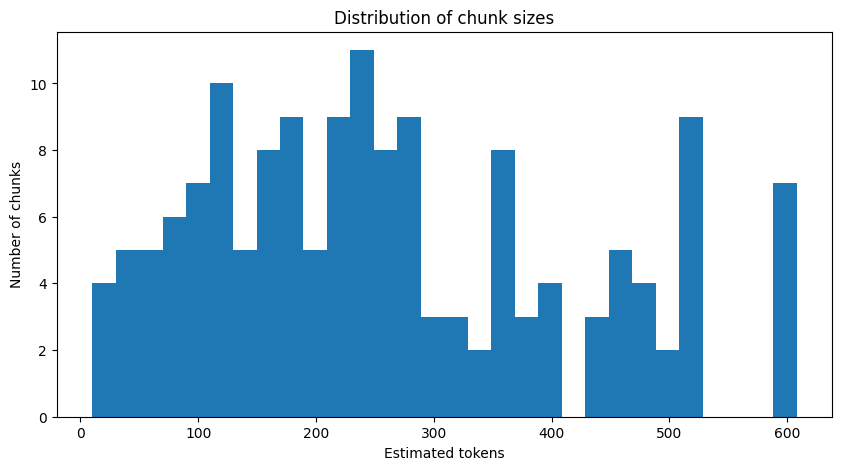

In [14]:
plt.figure(figsize=(10, 5))
plt.hist([chunk["token_count"] for chunk in chunks], bins=30)
plt.xlabel("Estimated tokens")
plt.ylabel("Number of chunks")
plt.title("Distribution of chunk sizes")
plt.show()


## 13. Threshold quality check

This quick check shows how many chunks fall into the main size bands:
- below 180 tokens
- between 180 and 349
- between 350 and 550
- above 550

The ideal outcome is that most text chunks remain in the preferred range or near it, while still preserving structure.


In [15]:
def count_by_size_band(chunks: List[Dict[str, Any]]) -> Dict[str, int]:
    counts = {
        "below_180": 0,
        "between_180_349": 0,
        "between_350_550": 0,
        "above_550": 0,
    }

    for chunk in chunks:
        t = chunk["token_count"]
        if t < 180:
            counts["below_180"] += 1
        elif 180 <= t <= 349:
            counts["between_180_349"] += 1
        elif 350 <= t <= 550:
            counts["between_350_550"] += 1
        else:
            counts["above_550"] += 1

    return counts


size_band_counts = count_by_size_band(chunks)
size_band_counts


{'below_180': 55, 'between_180_349': 54, 'between_350_550': 38, 'above_550': 7}

## 14. Sample outputs

Finally, we inspect a few examples:
- 3 normal chunks
- 1 split example
- 1 table chunk

This makes it easier to manually verify whether the chunking logic is preserving the original section meaning.


In [16]:
def print_chunk_preview(chunk: Dict[str, Any], max_chars: int = 700):
    print("=" * 100)
    print(f"chunk_id     : {chunk['chunk_id']}")
    print(f"type         : {chunk['type']}")
    print(f"section_id   : {chunk['section_id']}")
    print(f"chunk_index  : {chunk['chunk_index']}")
    print(f"title        : {chunk['title']}")
    print(f"section_no   : {chunk['section_number']}")
    print(f"page_num     : {chunk['page_num']}")
    print(f"level        : {chunk['level']}")
    print(f"token_count  : {chunk['token_count']}")
    print("-" * 100)
    preview = chunk["text"][:max_chars]
    print(preview + ("..." if len(chunk["text"]) > max_chars else ""))
    print()


normal_chunks = [c for c in chunks if c["type"] == "text" and c["chunk_index"] == "1/1"][:3]

for chunk in normal_chunks:
    print_chunk_preview(chunk)


chunk_id     : EMV_Book_2_v4.4_12_PartI.1_text_1
type         : text
section_id   : EMV_Book_2_v4.4_12_PartI.1
chunk_index  : 1/1
title        : Scope
section_no   : PartI.1
page_num     : 12
level        : 1
token_count  : 109
----------------------------------------------------------------------------------------------------
This document, the Integrated Circuit Card Specifications for Payment SystemsBook 4, Cardholder, Attendant, and Acquirer Interface Requirements for Payment Systems , defines the mandatory, recommended, and optional terminal requirements necessary to support the acceptance of integrated circuit cards (ICCs) in accordance with the other documents of the Integrated Circuit Card Specifications for Payment Systems , all available on http://www.emvco.com:

- Book 1 – Application Independent ICC to Terminal Interface Requirements
- Book 2 – Security and Key Management
- Book 3 – Application Specification

chunk_id     : EMV_Book_2_v4.4_12_PartI.1.1_text_1
type         :

In [17]:
split_example = None
for section_id, count in summary["split_sections"].items():
    if count > 1:
        related = [c for c in chunks if c["section_id"] == section_id and c["type"] == "text"]
        split_example = related
        break

if split_example:
    for chunk in split_example:
        print_chunk_preview(chunk)
else:
    print("No split example found in this dataset.")


chunk_id     : EMV_Book_2_v4.4_15_PartI.2_text_1
type         : text
section_id   : EMV_Book_2_v4.4_15_PartI.2
chunk_index  : 1/2
title        : Normative References
section_no   : PartI.2
page_num     : 15
level        : 1
token_count  : 512
----------------------------------------------------------------------------------------------------
The following specifications and standards contain provisions that are referenced in these specifications. The latest version shall apply unless a publication date is explicitly stated.

EMV Contact Interface Specification

EMV Level 1 Specifications for Payment Systems, EMV Contact Interface Specification

EMV Tokenisation Framework

EMV Payment Tokenisation Specification – Technical Framework

Framework specification for an interoperable Payment Tokenisation solution.

FIPS 202 : SHA3 Standard: PermutationBased Hash and

ExtendableOutput Functions

IEEE P1363 : Standard Specifications For PublicKey Cryptography

ISO 6391 : Codes for the represent

In [18]:
table_example = next((c for c in chunks if c["type"] == "table"), None)

if table_example:
    print_chunk_preview(table_example, max_chars=700)
else:
    print("No table chunk found in this dataset.")


chunk_id     : EMV_Book_2_v4.4_38_PartII.5.1_table_1
type         : table
section_id   : EMV_Book_2_v4.4_38_PartII.5.1
chunk_index  : 1/1
title        : Terminal Types
section_no   : PartII.5.1
page_num     : 38
level        : 2
token_count  : 226
----------------------------------------------------------------------------------------------------
Table 1: Terms Describing Terminal Types
Columns: Term | Definition || Attended ; An attendant (an agent of the merchant or of the acquirer) is present at the point of transaction and participates in the transaction by entering transaction-related data. The transaction occurs 'face to face'. || Unattended ; The cardholder conducts the transaction at the point of transaction without the participation of an attendant (agent of the merchant or of the acquirer). The transaction does not occur 'face to face'. || Online only ; The transaction can normally only be approved in real time by transmission of an authorisation request message. || Offline w

## 15. Optional export

If needed, the final chunks can be saved as a JSON file for the embedding stage.


In [19]:
OUTPUT_PATH = input_path.parent / "adaptive_chunks.json"

with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    json.dump(chunks, f, ensure_ascii=False, indent=2)

print(f"Saved chunked output to: {OUTPUT_PATH}")


Saved chunked output to: ../../../data/processed/book4/done/adaptive_chunks.json
